Analiza datelor ATP

In acest notebook analizez datele din meciuri ATP pentru a intelege ce factori influenteaza rezultatul unui meci de tenis.

In [10]:
import pandas as pd

df = pd.read_csv("atp_matches_till_2022.csv")
df.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,1968-2029,Dublin,Grass,32,A,19680708,270,112411,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1968-2029,Dublin,Grass,32,A,19680708,271,126914,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1968-2029,Dublin,Grass,32,A,19680708,272,209523,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1968-2029,Dublin,Grass,32,A,19680708,273,100084,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1968-2029,Dublin,Grass,32,A,19680708,274,100132,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188161 entries, 0 to 188160
Data columns (total 49 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   tourney_id          188161 non-null  object 
 1   tourney_name        188161 non-null  object 
 2   surface             185844 non-null  object 
 3   draw_size           188161 non-null  int64  
 4   tourney_level       188161 non-null  object 
 5   tourney_date        188161 non-null  int64  
 6   match_num           188161 non-null  int64  
 7   winner_id           188161 non-null  int64  
 8   winner_seed         69694 non-null   float64
 9   winner_entry        16270 non-null   object 
 10  winner_name         188161 non-null  object 
 11  winner_hand         188144 non-null  object 
 12  winner_ht           171924 non-null  float64
 13  winner_ioc          188151 non-null  object 
 14  winner_age          186826 non-null  float64
 15  loser_id            188161 non-nul

Datasetul contine informatii despre meciuri ATP, inclusiv jucatori, turnee, suprafata si statistici despre performanta jucatorilor.

In [12]:
df.describe()

,draw_size,tourney_date,match_num,winner_id,winner_seed,winner_ht,winner_age,loser_id,loser_seed,loser_ht,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
count,188161.000000,1.881610e+05,188161.000000,188161.000000,69694.000000,171924.000000,186826.000000,188161.000000,35337.000000,159463.000000,...,92219.000000,92219.000000,92219.000000,92220.000000,92219.000000,92219.000000,153197.000000,105973.000000,144834.000000,104354.000000
mean,52.926292,1.993350e+07,76.618598,103820.251673,6.280225,184.449187,25.658362,104967.986995,7.667402,184.226592,...,48.011549,31.894892,14.985263,12.197387,4.812002,8.742884,75.255716,1366.471611,112.884150,859.219896
std,36.446303,1.544445e+05,110.714957,11470.048991,5.509548,6.667033,4.045128,14866.251405,5.995551,6.655036,...,19.390121,14.449465,7.220377,4.129834,3.275387,4.131839,121.053512,1726.089469,162.191701,987.192154
min,2.000000,1.968011e+07,1.000000,100001.000000,1.000000,160.000000,14.300000,100001.000000,1.000000,160.000000,...,0.000000,0.000000,0.000000,0.000000,-6.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,32.000000,1.980041e+07,10.000000,100402.000000,2.000000,180.000000,22.700000,100502.000000,4.000000,180.000000,...,34.000000,22.000000,10.000000,9.000000,2.000000,6.000000,17.000000,489.000000,37.000000,361.000000
50%,32.000000,1.993030e+07,25.000000,101686.000000,5.000000,185.000000,25.200000,101843.000000,6.000000,185.000000,...,45.000000,29.000000,14.000000,11.000000,4.000000,8.000000,44.000000,846.000000,70.000000,630.000000
75%,64.000000,2.006072e+07,80.000000,103898.000000,8.000000,188.000000,28.200000,104252.000000,10.000000,188.000000,...,58.000000,40.000000,19.000000,15.000000,7.000000,11.000000,86.000000,1532.000000,118.000000,1013.000000
max,128.000000,2.022113e+07,1701.000000,211468.000000,35.000000,211.000000,58.700000,211805.000000,35.000000,211.000000,...,328.000000,284.000000,101.000000,91.000000,28.000000,38.000000,2101.000000,16950.000000,2159.000000,16950.000000


In [13]:
df.isnull().sum()

tourney_id                 0
tourney_name               0
surface                 2317
draw_size                  0
tourney_level              0
tourney_date               0
match_num                  0
winner_id                  0
winner_seed           118467
winner_entry          171891
winner_name                0
winner_hand               17
winner_ht              16237
winner_ioc                10
winner_age              1335
loser_id                   0
loser_seed            152824
loser_entry           160432
loser_name                 0
loser_hand                64
loser_ht               28698
loser_ioc                 69
loser_age               4825
score                      8
best_of                    0
round                      0
minutes                98650
w_ace                  95941
w_df                   95942
w_svpt                 95942
w_1stIn                95942
w_1stWon               95942
w_2ndWon               95942
w_SvGms                95941
w_bpSaved     

In [14]:
df = df.dropna(subset=["winner_rank", "loser_rank"])

In [15]:
df["rank_diff"] = df["winner_rank"] - df["loser_rank"]

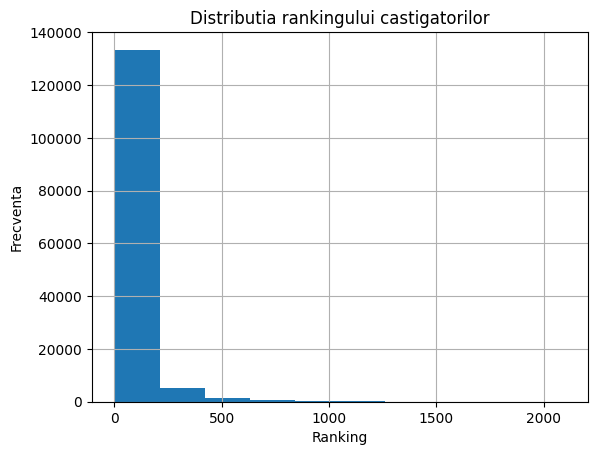

In [16]:
import matplotlib.pyplot as plt

df["winner_rank"].hist()
plt.title("Distributia rankingului castigatorilor")
plt.xlabel("Ranking")
plt.ylabel("Frecventa")
plt.show()

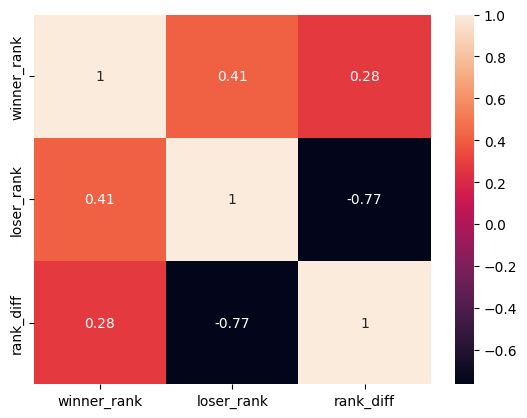

In [17]:
import seaborn as sns

corr = df[["winner_rank","loser_rank","rank_diff"]].corr()
sns.heatmap(corr, annot=True)
plt.show()

Concluzii

In urma analizei datelor se observa ca rankingul jucatorilor influenteaza rezultatul unui meci. Diferenta de ranking (rank_diff) are o corelatie negativa puternica cu rankingul jucatorului invins, ceea ce indica faptul ca jucatorii mai bine clasati au sanse mai mari de castig.

Aceste informatii pot fi folosite in viitor pentru a construi un model de Machine Learning care sa prezica castigatorul unui meci de tenis.

In [18]:

# FEATURE ENGINEERING 


# asiguram ca df exista
if 'df' not in globals():
    raise ValueError("DataFrame-ul df nu este definit. Verifica citirea datelor.")

df = df.copy()

# eliminam valori lipsa pentru coloanele importante
df = df.dropna(subset=["winner_rank", "loser_rank", "winner_age", "loser_age", "winner_ht", "loser_ht"])

# diferenta ranking
df["rank_diff"] = df["winner_rank"] - df["loser_rank"]

# diferenta varsta
df["age_diff"] = df["winner_age"] - df["loser_age"]

# diferenta inaltime
df["height_diff"] = df["winner_ht"] - df["loser_ht"]
df["advantage_score"] = (
    (-df["rank_diff"] * 0.7) +
    (-abs(df["age_diff"]) * 0.2) +
    (df["height_diff"] * 0.1)
)

print("Features create:")
print(df[[
    "rank_diff",
    "age_diff", 
    "height_diff",
    "advantage_score"
]].head())

Features create:
       rank_diff  age_diff  height_diff  advantage_score
17345      -79.0       8.0         -5.0            53.20
17346      -93.0      -2.9         -2.0            64.32
17347       -7.0     -10.8         -5.0             2.24
17348      -35.0       4.7        -12.0            22.36
17350      -51.0       4.9          2.0            34.92


In [19]:


df_model = df.copy()
df_model["target"] = 1  # winner castiga

df_reverse = df.copy()
df_reverse["target"] = 0  # loser castiga (invers)

# inversam jucatorii
df_reverse = df_reverse.rename(columns={
    "winner_rank": "loser_rank",
    "loser_rank": "winner_rank",
    "winner_age": "loser_age",
    "loser_age": "winner_age",
    "winner_ht": "loser_ht",
    "loser_ht": "winner_ht"
})

# combinam
df_final = pd.concat([df_model, df_reverse])

print("Dimensiune dataset final:", df_final.shape)

Dimensiune dataset final: (265208, 54)


In [20]:
df_final["rank_diff"] = df_final["winner_rank"] - df_final["loser_rank"]
df_final["age_diff"] = df_final["winner_age"] - df_final["loser_age"]
df_final["height_diff"] = df_final["winner_ht"] - df_final["loser_ht"]

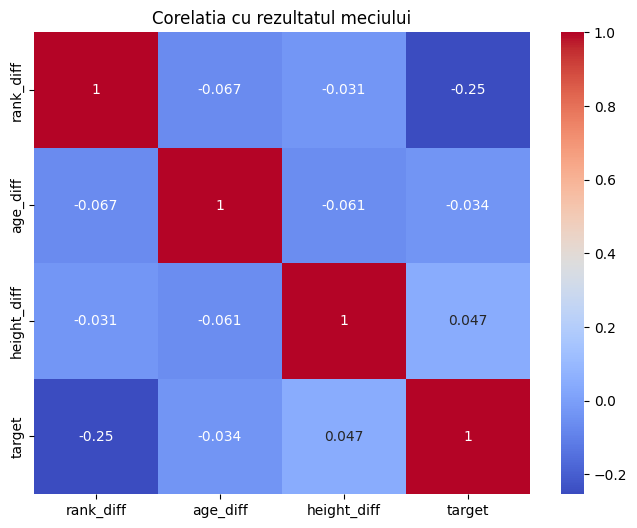

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["rank_diff", "age_diff", "height_diff"]

corr = df_final[features + ["target"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Corelatia cu rezultatul meciului")
plt.show()

In [22]:
from sklearn.ensemble import RandomForestClassifier

X = df_final[features]
y = df_final["target"]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_

for name, val in zip(features, importances):
    print(f"{name}: {val}")

rank_diff: 0.49271343947612667
age_diff: 0.3969779809615068
height_diff: 0.11030857956236659


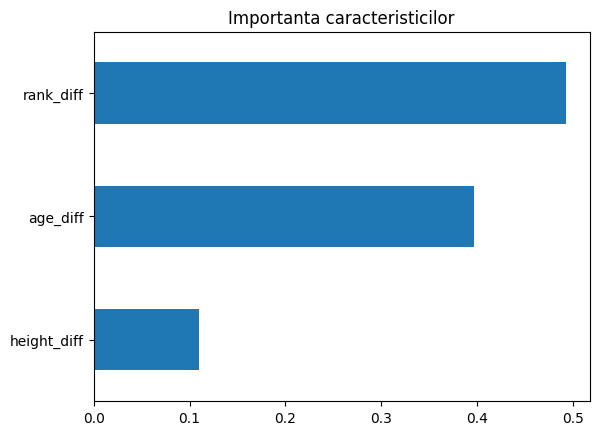

In [23]:
import pandas as pd

feat_importance = pd.Series(importances, index=features)
feat_importance.sort_values().plot(kind='barh')

plt.title("Importanta caracteristicilor")
plt.show()

In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# verificare date
if 'df' not in globals():
    raise ValueError("DataFrame-ul df nu este definit.")

# doua perspective pentru fiecare meci
df_win = df.copy()
df_win["target"] = 1

df_lose = df.copy()
df_lose["target"] = 0

df_lose["rank_diff"] = -df["rank_diff"]
df_lose["age_diff"] = -df["age_diff"]
df_lose["height_diff"] = -df["height_diff"]
df_lose["advantage_score"] = -df["advantage_score"]

df_final = pd.concat([df_win, df_lose], ignore_index=True)

features = [
    "rank_diff",
    "age_diff",
    "height_diff",
    "advantage_score"
]

df_final = df_final.dropna(subset=features)

X = df_final[features]
y = df_final["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Date pregatite cu succes.")

Date pregatite cu succes.


Logistic Regression

In [27]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, pred_log)

print("Accuracy Logistic Regression:", acc_log)

Accuracy Logistic Regression: 0.9970400814448928


Random forest

In [28]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=3,
    scoring="accuracy"
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

pred_rf = best_rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)

print("Accuracy Random Forest:", acc_rf)
print("Best params:", rf_grid.best_params_)

Accuracy Random Forest: 0.7395083141661325
Best params: {'max_depth': 10, 'n_estimators': 100}


Gradient Boosting

In [29]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

pred_gb = gb_model.predict(X_test)
acc_gb = accuracy_score(y_test, pred_gb)

print("Accuracy Gradient Boosting:", acc_gb)

Accuracy Gradient Boosting: 0.7032728780966027


Comparare finala

In [30]:
rezultate = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        acc_log,
        acc_rf,
        acc_gb
    ]
})

print("Comparatie modele:")
print(rezultate.sort_values(by="Accuracy", ascending=False))

print("\nRaport Random Forest:")
print(classification_report(y_test, pred_rf))

Comparatie modele:
                 Model  Accuracy
0  Logistic Regression  0.997040
1        Random Forest  0.739508
2    Gradient Boosting  0.703273

Raport Random Forest:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74     26521
           1       0.74      0.74      0.74     26521

    accuracy                           0.74     53042
   macro avg       0.74      0.74      0.74     53042
weighted avg       0.74      0.74      0.74     53042

